# Desafiament 4 — Competencias Financieras (ECF 2021)

Análisis de competencias financieras (conocimiento, actitudes, comportamiento y planificación de la jubilación) a partir de la Encuesta de Competencias Financieras (ECF) 2021, para responder a la pregunta de negocio del reto 4 sobre adaptación de la oferta de Banco Atlas a las tendencias nacionales.

## 0. Tabla de referencia — Variables de Competencias Financieras

Códigos originales de la ECF 2021 (sin traducir). Estado según el pipeline actual del notebook.

### Bloque D — Actitudes (usadas en `score_actitud`)

| Código | Pregunta |
|---|---|
| `d0101` | Antes de comprar algo, considero cuidadosamente si me lo puedo permitir |
| `d0102` | Tiendo a vivir al día, sin pensar en el futuro |
| `d0103` | Prefiero gastar dinero ahora, que ahorrarlo para el futuro |
| `d0104` | Pago las facturas a tiempo |
| `d0105` | Estoy dispuesto a arriesgar un poco de dinero al ahorrar o realizar una inversión, si así puedo obtener un mayor rendimiento en el futuro |
| `d0106` | Vigilo cuidadosamente mis asuntos financieros |
| `d0107` | Me he fijado objetivos financieros a largo plazo y me esfuerzo por alcanzarlos |
| `d0108` | El dinero está para gastarlo |
| `d0109` | Mi situación financiera limita mis posibilidades de hacer cosas que considero importantes |
| `d0110` | Me preocupo por pagar mis gastos habituales |
| `d0111` | Estoy demasiado endeudado ahora mismo |
| `d0112` | Estoy satisfecho con mi situación financiera actual |
| `d0113` | Intento mantenerme informado sobre la evolución de la economía |
| `d0114` | Me preocupa que mi dinero no dure |
| `d0115` | Estoy demasiado ocupado para encargarme de mis finanzas |
| `d0116` | Prefiero comprar cosas con crédito en vez de esperar y ahorrar |
| `d0117` | Pensar en mi situación financiera me genera inquietud |

### Bloque E — Conocimiento financiero (usadas en `score_conocimiento`)

| Código | Pregunta |
|---|---|
| `e0100` | ¿Cómo calificaría sus conocimientos generales sobre temas financieros? (no puntuable, solo autopercepción) |
| `e0500` | Reparto de 1.000€ entre 5 hermanos |
| `e0600` | Reparto tras un año con 1% de inflación |
| `e0700` | Interés de un préstamo entre amigos |
| `e0800` | Interés simple a 1 año |
| `e0900` | Interés compuesto a 5 años |
| `e1001` | Rentabilidad alta = riesgo alto (V/F) |
| `e1002` | Inflación = coste de vida aumenta (V/F) |
| `e1003` | Diversificación reduce riesgo (V/F) |
| `e1101` | Rendimiento de fondos a 6 años (cartón 35) |
| `e1200` | Hipoteca a 15 vs. 30 años (V/F) |
| `e1300` | Confianza en las respuestas del quiz (cargada, no puntuable — no tiene respuesta "correcta") |
| `e1701`/`e1702` | Tipo de interés conveniente para préstamo/ahorro |

### Bloque C — Planificación de la jubilación (usadas en `confianza_jubilacion`)

| Código | Pregunta |
|---|---|
| `c0100` | Confianza en la planificación (si no jubilado) |
| `c0300` | Edad esperada de jubilación (cargada, no explotada aún) |
| `c0500` | Confianza en la planificación (si ya jubilado) |

### Variables comunes de segmentación (Grupo A)

| Código | Pregunta |
|---|---|
| `a04` | Edad |
| `a0000` | Género |
| `a0100` | País de nacimiento (cargada, no explotada) |
| `a1030` | Estado civil (cargada, no explotada) |
| `a1100` | Educación — usada en cruces |
| `a1500`/`a1510` | Situación laboral — usada en cruces |
| `a1800` | Ocupación CNO-2011 (cargada, no explotada) |
| `ccaaf` | Comunidad Autónoma (cargada, no explotada) |

### Pendiente / cargado pero sin usar en el análisis final

| Código | Motivo |
|---|---|
| `c0200a`-`c0200k`, `c0600a`-`c0600k` | Fuentes de ingreso en jubilación — la reducción de multirrespuesta la gestiona Roger en el Master Dataset |
| `b1230a`-`b1230h` | "A quién acudiría" — mismo motivo |
| `f1100` | Quién tiene más conocimiento en el hogar — cargada, sin cruce realizado |

### Descartadas del análisis (documentadas en su momento, nunca incorporadas al pipeline)

| Código | Motivo |
|---|---|
| `a1420a`-`a1420g` | Formación financiera recibida — nunca se añadió a `COMMON_VARS`/`FINANCIAL_COMPETENCIES` |
| `d0300`-`d0500`, `d0610a`-`d0610e` | Preferencia temporal / reparto de ingreso extra — nunca se cargaron |
| `e1400`, `e1500`, `e1600`, `e1800`, `e0300`, `e0401`, `e0402` | Numeracia/razonamiento general — excluidas deliberadamente por no ser competencia financiera específica |

## 1. Tipificación de variables

Tratamiento aplicado a cada tipo de variable dentro del bloque de Competencias:

| Tipo | Variables | Tratamiento aplicado |
|---|---|---|
| Escala Likert 1-5 (frecuencia: 1=Nunca, 5=Siempre) | `d0101`-`d0117` | Convertidas a numérico con `likert_score()`; ítems negativos invertidos (`6 - valor`); combinadas en `score_actitud` (media) |
| Escala 1-5 de confianza, filtrada por situación laboral | `c0100`, `c0500` | Convertidas con `likert_score()` y combinadas en `confianza_jubilacion` (`c0100` si no jubilado, `c0500` si jubilado) |
| Numéricas abiertas | `e0500`, `e0700`, `e0800`, `e0900` | Puntuadas correcto/incorrecto contra el valor exacto esperado |
| Verdadero/Falso | `e1001`, `e1002`, `e1003`, `e1200` | Comparación directa contra `"Verdadero"` |
| Categórica con respuesta correcta única | `e1101` (Fondo 1), `e1701`/`e1702` (tipo de interés) | Comparación directa contra el valor esperado, mismo tratamiento que V/F |
| Suma de aciertos | `e0500`-`e1702` (los 12 anteriores) | `score_conocimiento` (0-12), vía `puntuar_quiz_conocimiento()` |
| Escala 1-10, cargada pero sin uso | `e1300` | Cargada en `df_comp`; no se puntúa (no tiene respuesta correcta) ni se ha cruzado con nada todavía |

**Pendiente / gap conocido:** ni `c0100` ni `c0500` tienen implementado el flag binario para la categoría especial "no tengo plan de jubilación" que se había previsto en su momento — de momento se tratan como escala continua sin ese matiz. No bloquea las conclusiones actuales, pero conviene mencionarlo si alguien pregunta por qué no aparece esa distinción.

**Ya resuelto (nota antigua eliminada):** el notebook no depende del `MasterDataset.csv` de Roger para la construcción de `df_comp` — se trabaja directamente sobre `2026-07-20_ECF_2021_01_raw.dta`, por lo que el nombrado de columnas del master de Roger es irrelevante para este pipeline (solo se usa puntualmente en el ANEXO de comparación de scores).

# 2. Preparació de dades

## 2.0.1 Imports biblioteques

In [25]:
import pandas as pd
from pathlib import Path

## 2.0.2 Importació dades

In [26]:
# # Rutas relativas desde Scripts/ hacia ../Data/
# data_dir = Path("../Data")
# input_file = data_dir / "2026-07-20_ECF_2021_02_MasterDataset.csv"
# df_comp = pd.read_csv(input_file)
# df_comp.head()

In [27]:

data_dir = Path("../Data")
raw_file = data_dir / "2026-07-20_ECF_2021_01_raw.dta"

df = pd.read_stata(raw_file, convert_categoricals=True)
print(df.shape)

(7764, 429)


In [28]:
COMMON_VARS = [
    "a04",      # Edad
    "a0000",    # Sexo
    "a0100",    # País de nacimiento
    "a1030",    # Estado civil
    "a1100",    # Educación
    "a1500",    # Situación laboral
    "a1510",
    "a1800",    # Ocupación CNO-2011
    "ccaaf",    # Comunidad Autónoma
]

FINANCIAL_COMPETENCIES = [
    "e0100",
    "e0500", "e0600", "e0700", "e0800", "e0900",
    "e1001", "e1002", "e1003", "e1101", "e1200",
    "e1300", "e1701", "e1702",
    "c0100", "c0300", "c0500",
]

# ATTITUDES — bloque d0101-d0117, tratado como propio de Competencias
ATTITUDES = [f"d01{n:02d}" for n in range(1, 18)]

cols_needed = COMMON_VARS + FINANCIAL_COMPETENCIES + ATTITUDES

faltantes = [c for c in cols_needed if c not in df.columns]
print("Faltantes:", faltantes)

df_comp = df[[c for c in cols_needed if c in df.columns]].copy()

COLUMNAS_NUMERICAS = ["a04", "e0500", "e0700", "e0800"]
for col in COLUMNAS_NUMERICAS:
    df_comp[col] = pd.to_numeric(df_comp[col], errors="coerce")

print(df_comp.shape)

Faltantes: []
(7764, 43)


In [29]:
COLUMNAS_NUMERICAS = ["a04", "e0500", "e0700", "e0800"]

for col in COLUMNAS_NUMERICAS:
    df_comp[col] = pd.to_numeric(df_comp[col], errors="coerce")

df_comp[COLUMNAS_NUMERICAS].describe()

,a04,e0500,e0700,e0800
count,7755.000000,7450.000000,7673.000000,6303.000000
mean,46.941586,267.938416,0.388523,133.597947
std,15.643214,1990.368653,9.504984,318.956813
min,18.000000,-5.000000,-5.000000,-5.000000
25%,35.000000,200.000000,0.000000,102.000000
50%,47.000000,200.000000,0.000000,102.000000
75%,59.000000,200.000000,0.000000,102.000000
max,80.000000,170000.000000,500.000000,12500.000000


## 2.1 Neteja general codis especials

In [30]:
# ============================================================
# 2.1 NETEJA GENERAL DE CODIS ESPECIALS
# ============================================================
CODIGOS_ESPECIALES = [-97, -98, -99, -5]
TEXTOS_ESPECIALES = ["No sabe", "No contesta", "No ha lugar (no aplica filtro)"]

def limpiar_codigos_especiales(df, columnas, codigos=CODIGOS_ESPECIALES, textos=TEXTOS_ESPECIALES):
    df_limpio = df.copy()
    valores_txt = [str(v) for v in codigos] + list(textos)
    for col in columnas:
        s = df_limpio[col]
        if pd.api.types.is_numeric_dtype(s):
            df_limpio[col] = s.mask(s.isin(codigos))
        else:
            df_limpio[col] = s.mask(s.astype("string").isin(valores_txt))
    return df_limpio

df_comp = limpiar_codigos_especiales(df_comp, df_comp.columns)

## 2.2 Puntuació del quiz coneixement

In [31]:
# ============================================================
# 2.2 PUNTUACIÓN DEL QUIZ DE CONOCIMIENTO
# ============================================================
RESPUESTAS_CORRECTAS = {
    "e0500": 200,
    "e0600": "c. Menos de lo que podrían comprar hoy",
    "e0700": 0,
    "e0800": 102,
    "e0900": "Más de 110 euros",
    "e1001": "Verdadero",
    "e1002": "Verdadero",
    "e1003": "Verdadero",
    "e1101": "Fondo 1 (Azul)",
    "e1200": "Verdadero",
    "e1701": "Tipo de interés del 1%",
    "e1702": "Tipo de interés del 3%",
}

def puntuar_quiz_conocimiento(df, respuestas_correctas=RESPUESTAS_CORRECTAS):
    df_score = df.copy()
    columnas_score = []
    for var, ok in respuestas_correctas.items():
        col = f"{var}_correcta"
        df_score[col] = (df_score[var] == ok).astype("Int64")
        df_score.loc[df_score[var].isna(), col] = pd.NA
        columnas_score.append(col)
    df_score["score_conocimiento"] = df_score[columnas_score].sum(axis=1, min_count=1)
    return df_score

df_comp = puntuar_quiz_conocimiento(df_comp)

print("Distribución score_conocimiento (0-12):")
print(df_comp["score_conocimiento"].value_counts().sort_index())
print(f"\nMedia: {df_comp['score_conocimiento'].mean():.2f}")

Distribución score_conocimiento (0-12):
score_conocimiento
0        1
1       12
2       44
3       80
4      181
5      336
6      597
7      838
8     1074
9     1346
10    1377
11    1173
12     703
Name: count, dtype: Int64

Media: 8.76


## 2.3 Score Actituds

In [32]:
# ============================================================
# 2.3 SCORE DE ACTITUDES (media Likert, ítems negativos invertidos)
# ============================================================
def likert_score(s):
    return pd.to_numeric(s.astype("string").str.extract(r"^\s*(\d+)", expand=False), errors="coerce")

ITEMS_POSITIVOS = ["d0101", "d0104", "d0105", "d0106", "d0107", "d0113"]
ITEMS_NEGATIVOS = ["d0102", "d0103", "d0108", "d0109", "d0110", "d0114", "d0115", "d0116", "d0117"]

for col in ITEMS_POSITIVOS + ITEMS_NEGATIVOS:
    df_comp[f"{col}_num"] = likert_score(df_comp[col])

vals = pd.DataFrame(index=df_comp.index)
for c in ITEMS_POSITIVOS:
    vals[c] = df_comp[f"{c}_num"]
for c in ITEMS_NEGATIVOS:
    vals[c] = 6 - df_comp[f"{c}_num"]

df_comp["score_actitud"] = vals.mean(axis=1, skipna=True)



## 2.4 Tramos de edad

In [ ]:
# ============================================================
# 2.4 TRAMOS DE EDAD (alineados con los grupos de edad del INE)
# ============================================================
bins=[17,24,34,44,54,64,79],
labels=[
        "18-24 Jóvenes",
        "25-34 Jóvenes adultos",
        "35-44 Adultos iniciales",
        "45-54 Adultos maduros",
        "55-64 Mediana edad",
        "65-79 Sénior"
    ]

df_comp["tramo_edad"] = pd.cut(
    df_comp["a04"],
    bins=bins,
    labels=labels,
    right=True
)


## 2.5 Primer encreuaments

In [34]:
# ============================================================
# 5. PRIMEROS CRUCES
# ============================================================
print("\n--- Score conocimiento por tramo de edad ---")
print(df_comp.groupby("tramo_edad", observed=True)["score_conocimiento"].agg(["mean", "count"]))

print("\n--- Score conocimiento por nivel educativo ---")
print(df_comp.groupby("a1100", observed=True)["score_conocimiento"].agg(["mean", "count"]).sort_values("mean"))

print("\n--- Score conocimiento por situación laboral ---")
print(df_comp.groupby("a1500", observed=True)["score_conocimiento"].agg(["mean", "count"]).sort_values("mean"))

print("\n--- Score actitud por tramo de edad ---")
print(df_comp.groupby("tramo_edad", observed=True)["score_actitud"].agg(["mean", "count"]))


--- Score conocimiento por tramo de edad ---
                              mean  count
tramo_edad                               
Jóvenes (18-24)           8.107188    793
Jóvenes adultos (25-34)   8.809222   1106
Adultos iniciales(35-44)  9.035374   1470
Adultos maduros (45-54)   9.099389   1801
Mediana adad (55-64)      8.965181   1436
Senior (65+)              8.055798   1147

--- Score conocimiento por nivel educativo ---
                                                         mean  count
a1100                                                               
a. Menos de primaria Incluye analfabetos, perso...   5.147059     68
b. Educación primaria Incluye sabe leer y escri...   6.991184    794
c. Primera etapa de Educación Secundaria y similar   7.945253   1717
d. Segunda etapa de Educación Secundaria y similar   8.750273   1834
e. Educación postsecundaria no superior              9.020619     97
f. Enseñanzas de Formación Profesional de Grado...   9.197483   1033
g. Diplomaturas un

Coneixement financer: la corba en U que necessitàveu
El patró per edat és una U invertida clàssica: puja de joves a adults madurs (8,11 → 9,10) i torna a caure en el segment que més creix segons l'INE (65+: 8,06, el més baix de tots després dels joves). Aquesta és exactament la troballa que lliga les dues parts del vostre repte: el segment demogràfic que l'INE projecta com a creixent (65+) és precisament el que mostra menor competència financera mitjana. És un insight de negoci fort i directe per a la presentació: si Banco Atlas vol adaptar-se a l'envelliment poblacional, calen productes més simples o més acompanyament per a aquest segment, no només més oferta.

Educació: gradient perfecte, i és un bon senyal metodològic
De "menys de primària" (5,15) a "doctorat" (10,48), la progressió és monotònica i neta — cada nivell educatiu puja respecte a l'anterior sense excepcions. Més enllà de l'interès de negoci, això és una validació implícita que el vostre score es comporta com hauria: si un indicador de competència financera no correlacionés amb l'educació, seria motiu de sospita metodològica. Val la pena mencionar-ho a la justificació tècnica com a evidència de validesa.
Situació laboral: alerta amb una categoria

Els actius (autònoms 9,30, per compte d'altri 9,11) i estudiants (8,53) puntuen alt; "se ocupa del hogar" (7,24) i incapacitat permanent (7,67) puntuen baix. Però "Otros (especificar)" té n=5 — no el facis servir per treure cap conclusió ni el mostris a la presentació amb aquest pes, la mitjana de 5,6 no és fiable amb tan poca mostra.

Actitud: pla, gairebé sense variació per edat
Aquí el contrast amb el coneixement és el propi insight: mentre el coneixement varia molt per edat (8,06 a 9,10), l'actitud es manté pràcticament plana (3,37-3,46 sobre 5) en tots els trams. Això suggereix que les diferències de competència financera per edat vénen sobretot del coneixement après, no d'una actitud fonamentalment diferent cap als diners — un matís útil per no simplificar excessivament ("els joves/grans no els interessen les finances" seria una lectura incorrecta de les dades).

In [35]:
df_comp.groupby("tramo_edad", observed=True).size()

tramo_edad
Jóvenes (18-24)              793
Jóvenes adultos (25-34)     1106
Adultos iniciales(35-44)    1470
Adultos maduros (45-54)     1801
Mediana adad (55-64)        1436
Senior (65+)                1149
dtype: int64

# 3. Visualizaciones de datos
## 3.1 CONOCIMIENTO FINANCIERO POR RANGO DE EDAD

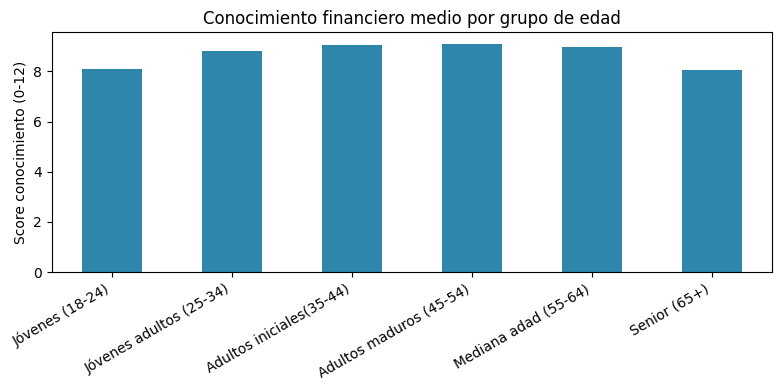

In [36]:
import matplotlib.pyplot as plt

resumen_edad = df_comp.groupby("tramo_edad", observed=True)["score_conocimiento"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
resumen_edad.plot(kind="bar", ax=ax, color="#2E86AB")
ax.set_ylabel("Score conocimiento (0-12)")
ax.set_xlabel("")
ax.set_title("Conocimiento financiero medio por grupo de edad")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
# plt.savefig("../Results/score_conocimiento_por_edad.png", dpi=150)
plt.show()

### 3.1.1 Conclusiones
1. El coneixement financer segueix una U invertida per edat; l'actitud es manté plana. El segment 65+ (el que l'INE projecta com el que més creix) té el segon score més baix de tots (8,06/12), només per sobre dels joves de 18-24.

2. L'educació és el predictor més net i monotònic (5,15 sense estudis → 10,48 doctorat) — el gradient més fort de tots els que hem mirat.

3. Els actius (autònoms/per compte d'altri) puntuen més alt que jubilats, aturats o "se ocupa del hogar" — situació laboral i edat es mouen junts però no diuen exactament el mateix.

## 3.2 CONOCIMIENTO FINANCIERO × TENENCIA DE PRODUCTOS BANCARIOS

In [37]:
# ============================================================
# 3.2 CONOCIMIENTO FINANCIERO × TENENCIA DE PRODUCTOS BANCARIOS
# (equivalentes ECF de housing/loan/deposit de Banco Atlas)
# ============================================================

productos_map = {
    "b0301": "tiene_hipoteca",       # equivalente a housing
    "b0306": "tiene_prestamo",       # equivalente a loan
    "b0308": "tiene_deposito_ahorro" # equivalente a deposit
}

df_productos = df[list(productos_map.keys())].copy()

df_productos = df_productos.rename(columns=productos_map)

for col in productos_map.values():
    df_productos[col] = (df_productos[col].astype("string").str.strip() == "Sí")

df_cruce = df_comp[["score_conocimiento", "score_actitud", "tramo_edad", "a1100"]].join(df_productos)

# --- Cruce 1: score medio según tenencia de cada producto ---
for col in productos_map.values():
    print(f"\n--- Score conocimiento según {col} ---")
    print(df_cruce.groupby(col, observed=True)["score_conocimiento"].agg(["mean", "count"]))

# --- Cruce 2: combinación Hipoteca + Depósito (el perfil dominante del reto 1-2) ---
df_cruce["hipoteca_y_deposito"] = (
    df_cruce["tiene_hipoteca"] & df_cruce["tiene_deposito_ahorro"]
)

print("\n--- Score conocimiento: perfil Hipoteca+Depósito vs resto ---")
print(df_cruce.groupby("hipoteca_y_deposito", observed=True)["score_conocimiento"].agg(["mean", "count"]))

# --- Cruce 3: número de productos financieros que tiene vs score ---
df_cruce["n_productos_basicos"] = (
    df_cruce["tiene_hipoteca"].astype(int)
    + df_cruce["tiene_prestamo"].astype(int)
    + df_cruce["tiene_deposito_ahorro"].astype(int)
)

print("\n--- Score conocimiento según número de productos ---")
print(df_cruce.groupby("n_productos_basicos", observed=True)["score_conocimiento"].agg(["mean", "count"]))


--- Score conocimiento según tiene_hipoteca ---
                    mean  count
tiene_hipoteca                 
False           8.515752   5396
True            9.322063   2366

--- Score conocimiento según tiene_prestamo ---
                    mean  count
tiene_prestamo                 
False           8.702321   6161
True            8.989382   1601

--- Score conocimiento según tiene_deposito_ahorro ---
                           mean  count
tiene_deposito_ahorro                 
False                   8.58453   6335
True                   9.547302   1427

--- Score conocimiento: perfil Hipoteca+Depósito vs resto ---
                         mean  count
hipoteca_y_deposito                 
False                8.681364   7212
True                 9.812727    550

--- Score conocimiento según número de productos ---
                         mean  count
n_productos_basicos                 
0                    8.298311   3731
1                    9.041431   2824
2                    

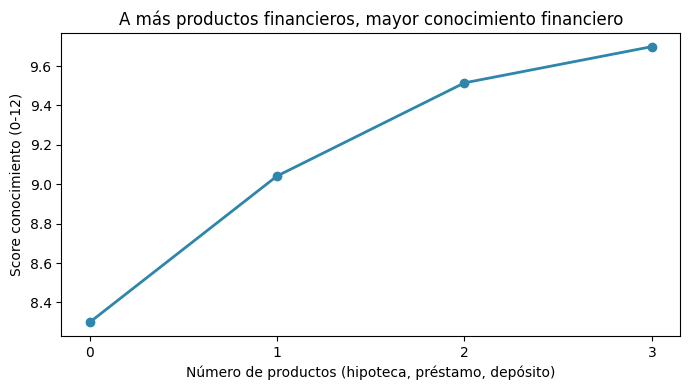

In [38]:
resumen_productos = df_cruce.groupby("n_productos_basicos", observed=True)["score_conocimiento"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
resumen_productos.plot(kind="line", marker="o", ax=ax, color="#2E86AB", linewidth=2)
ax.set_ylabel("Score conocimiento (0-12)")
ax.set_xlabel("Número de productos (hipoteca, préstamo, depósito)")
ax.set_title("A más productos financieros, mayor conocimiento financiero")
ax.set_xticks([0, 1, 2, 3])
plt.tight_layout()
# plt.savefig("../Results/score_conocimiento_por_n_productos.png", dpi=150)
plt.show()

### 3.2.1 Conclusiones 
- Existe un gradiente monotónico y sin excepciones entre número de productos financieros y conocimiento: 8,30 (0 productos) → 9,04 (1) → 9,51 (2) → 9,70 (3).
- El perfil "Hipoteca + Depósito" —identificado como dominante en los retos 1 y 2— es también el más competente financieramente: 9,81 frente a 8,68 del resto (la mayor brecha de todo el estudio).
- Por producto individual, el depósito de ahorro (8,58 → 9,55) y la hipoteca (8,52 → 9,32) muestran la asociación más fuerte con el conocimiento; el préstamo personal apenas la muestra (8,70 → 8,99).
- Advertencia metodológica: es correlación, no causalidad. No se puede afirmar si el conocimiento lleva a adquirir más productos o si la relación con el banco genera aprendizaje.

## 3.3 CONFIANZA JUBILACIÓN

In [39]:
score_c0100 = likert_score(df_comp["c0100"])
score_c0500 = likert_score(df_comp["c0500"])

df_comp["confianza_jubilacion"] = score_c0100.where(score_c0100.notna(), score_c0500)

print("--- Confianza en planificación de jubilación por grupo de edad ---")
print(df_comp.groupby("tramo_edad", observed=True)["confianza_jubilacion"].agg(["mean", "count"]))

print("\n--- Correlación confianza jubilación vs score_conocimiento ---")
print(df_comp[["confianza_jubilacion", "score_conocimiento"]].corr())

--- Confianza en planificación de jubilación por grupo de edad ---
                              mean  count
tramo_edad                               
Jóvenes (18-24)           2.830075    665
Jóvenes adultos (25-34)   2.767283   1027
Adultos iniciales(35-44)  2.929437   1403
Adultos maduros (45-54)   3.026605   1729
Mediana adad (55-64)      3.250549   1365
Senior (65+)               3.47886   1088

--- Correlación confianza jubilación vs score_conocimiento ---
                      confianza_jubilacion  score_conocimiento
confianza_jubilacion              1.000000            0.111933
score_conocimiento                0.111933            1.000000


                          confianza_jubilacion  score_conocimiento     n
tramo_edad                                                              
Jóvenes (18-24)                       2.830075            8.107188   665
Jóvenes adultos (25-34)               2.767283            8.809222  1027
Adultos iniciales(35-44)              2.929437            9.035374  1403
Adultos maduros (45-54)               3.026605            9.099389  1729
Mediana adad (55-64)                  3.250549            8.965181  1365
Senior (65+)                           3.47886            8.055798  1088


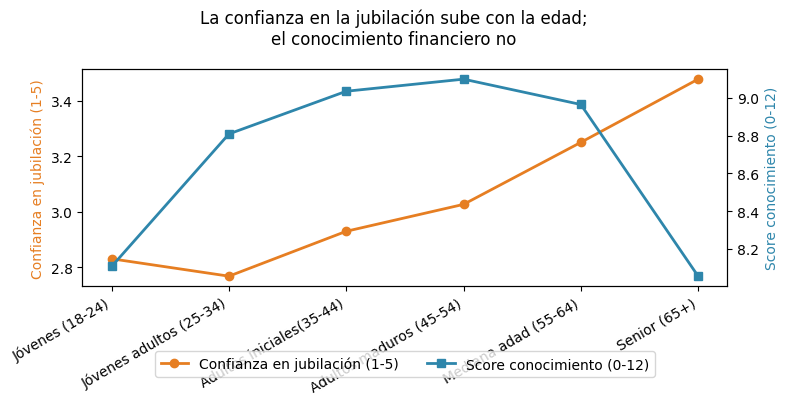

In [40]:
# ============================================================
# 3.3 Confianza en la planificación de la jubilación
# ============================================================
resumen_jubilacion = df_comp.groupby("tramo_edad", observed=True).agg(
    confianza_jubilacion=("confianza_jubilacion", "mean"),
    score_conocimiento=("score_conocimiento", "mean"),
    n=("confianza_jubilacion", "count"),
)
print(resumen_jubilacion)

fig, ax1 = plt.subplots(figsize=(8, 4.5))

x = range(len(resumen_jubilacion))
ax1.plot(x, resumen_jubilacion["confianza_jubilacion"], marker="o", color="#E67E22",
         linewidth=2, label="Confianza en jubilación (1-5)")
ax1.set_ylabel("Confianza en jubilación (1-5)", color="#E67E22")
ax1.set_xticks(list(x))
ax1.set_xticklabels(resumen_jubilacion.index, rotation=30, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, resumen_jubilacion["score_conocimiento"], marker="s", color="#2E86AB",
         linewidth=2, label="Score conocimiento (0-12)")
ax2.set_ylabel("Score conocimiento (0-12)", color="#2E86AB")

fig.suptitle("La confianza en la jubilación sube con la edad;\nel conocimiento financiero no")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower center", bbox_to_anchor=(0.5, -0.45), ncol=2)

plt.tight_layout()
# plt.savefig("../Results/confianza_vs_conocimiento_jubilacion.png", dpi=150)
plt.show()

### 3.3.1 Conclusiones
- La confianza en la planificación de la jubilación aumenta de forma constante con la edad (2,83 en 18-24 años → 3,48 en 65+), justo en dirección contraria al conocimiento financiero, que cae en ese mismo tramo.
- La correlación entre confianza y conocimiento es prácticamente nula (r=0,11): la confianza no está sustentada en un mayor conocimiento objetivo.
- Esto sugiere un riesgo de exceso de confianza (overconfidence) en el segmento 65+, el mismo que las proyecciones del INE identifican como creciente.
- Implicación de negocio: el segmento 65+ necesita productos acompañados de asesoramiento no por desconfianza propia, sino a pesar de la confianza que ya sienten — un matiz relevante para el mensaje comercial (evitar un tono que asuma desconfianza donde en realidad hay seguridad, quizás mal fundamentada).

## 3.4 CONFIANZA EN LA JUBILACIÓN POR SITUACIÓN LABORAL

In [41]:
print("--- Confianza en jubilación por situación laboral ---")
print(df_comp.groupby("a1500", observed=True)["confianza_jubilacion"].agg(["mean", "count"]).sort_values("mean"))

--- Confianza en jubilación por situación laboral ---
                                                     mean  count
a1500                                                           
d. Desempleado                                   2.582667    750
h. Estudiante, escolar o en formación            2.696347    438
Otros (especificar)                                   2.8      5
c. Se ocupa de su hogar                             2.912    375
f. No puede trabajar por incapacidad permanente   2.93662    142
b. Trabaja por cuenta ajena                      3.060639   3661
a. Trabaja por cuenta propia                     3.082045    841
g. No trabaja ni busca trabajo                   3.297297     37
e. Jubilado o jubilación anticipada              3.625363   1033


                                                 confianza_jubilacion  \
a1500                                                                   
d. Desempleado                                               2.582667   
h. Estudiante, escolar o en formación                        2.696347   
Otros (especificar)                                               2.8   
c. Se ocupa de su hogar                                         2.912   
f. No puede trabajar por incapacidad permanente               2.93662   
b. Trabaja por cuenta ajena                                  3.060639   
a. Trabaja por cuenta propia                                 3.082045   
g. No trabaja ni busca trabajo                               3.297297   
e. Jubilado o jubilación anticipada                          3.625363   

                                                 score_conocimiento     n  
a1500                                                                      
d. Desempleado                              

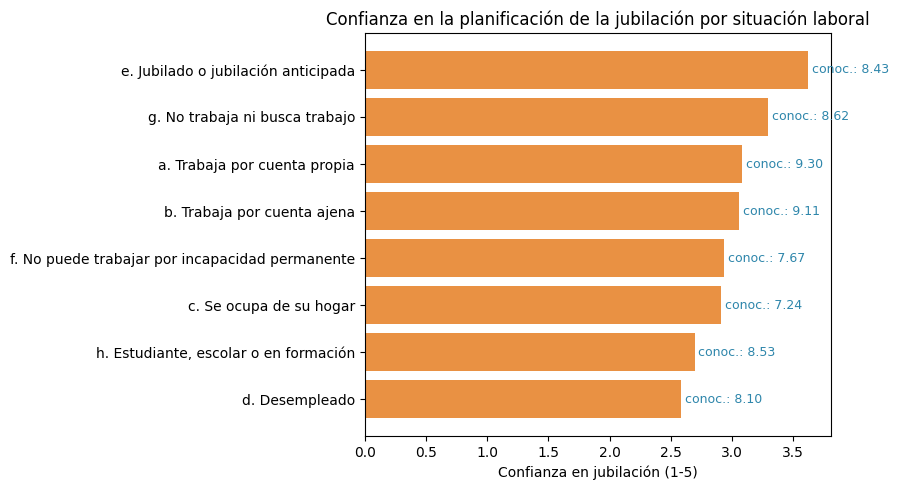

In [42]:
# ============================================================
# 3.4 Confianza en jubilación y conocimiento por situación laboral
# ============================================================
resumen_laboral = df_comp.groupby("a1500", observed=True).agg(
    confianza_jubilacion=("confianza_jubilacion", "mean"),
    score_conocimiento=("score_conocimiento", "mean"),
    n=("confianza_jubilacion", "count"),
).sort_values("confianza_jubilacion")

# Excluimos "Otros (especificar)" del gráfico por tamaño muestral insuficiente (n=5)
resumen_laboral_plot = resumen_laboral.drop(index="Otros (especificar)", errors="ignore")

print(resumen_laboral)

fig, ax = plt.subplots(figsize=(9, 5))
y = range(len(resumen_laboral_plot))

ax.barh(y, resumen_laboral_plot["confianza_jubilacion"], color="#E67E22", alpha=0.85, label="Confianza jubilación (1-5)")
ax.set_yticks(list(y))
ax.set_yticklabels(resumen_laboral_plot.index)
ax.set_xlabel("Confianza en jubilación (1-5)")
ax.set_title("Confianza en la planificación de la jubilación por situación laboral")

# Anotamos el score de conocimiento al lado de cada barra para contraste
for i, (conf, con) in enumerate(zip(resumen_laboral_plot["confianza_jubilacion"], resumen_laboral_plot["score_conocimiento"])):
    ax.text(conf + 0.03, i, f"conoc.: {con:.2f}", va="center", fontsize=9, color="#2E86AB")

plt.tight_layout()
# plt.savefig("../Results/confianza_conocimiento_por_situacion_laboral.png", dpi=150)
plt.show()

### 3.4.1 Conclusiones
- Los desempleados muestran la menor confianza en su planificación de jubilación (2,58), incluso por debajo de los estudiantes (2,70) — refleja cómo la inestabilidad laboral presente contamina la percepción sobre el futuro.
- Los jubilados presentan la mayor confianza (3,63), consistente con el patrón por edad ya visto en 3.3.
- Autónomos (3,08) y asalariados (3,06) muestran una confianza casi idéntica, pese a que los autónomos cuentan típicamente con una cobertura pública de pensión inferior por su régimen de cotización — una posible brecha entre confianza percibida y riesgo real (ver conclusión 5 del apartado 4).
- En conocimiento, el orden es distinto: autónomos (9,30) y asalariados (9,11) sí encabezan, mientras que confianza y conocimiento van en direcciones opuestas en desempleados y jubilados — mismo patrón de desacoplamiento visto por edad.

# 4. Conclusiones finales — Competencias Financieras

### Síntesis de hallazgos

1. **El conocimiento financiero sigue una U invertida por edad, con mínimo relativo en el segmento que más crece según el INE.** El grupo 65+ —que las proyecciones poblacionales sitúan como el de mayor crecimiento relativo hasta 2036— presenta el segundo score de conocimiento más bajo (8,06/12), solo por delante de los jóvenes de 18-24.

2. **La educación es el predictor más fuerte y consistente** (5,15 sin estudios → 10,48 doctorado), con un gradiente monotónico sin excepciones — la evidencia más clara de validez del índice construido.

3. **La tenencia de productos financieros se asocia con mayor competencia de forma gradual**: 8,30 (ningún producto) → 9,70 (los tres). El perfil "Hipoteca + Depósito", ya identificado como dominante en los retos 1 y 2, es también el más competente (9,81 frente a 8,68 del resto) — la mayor brecha de todo el estudio.

4. **La confianza en la planificación de la jubilación crece con la edad mientras el conocimiento no lo hace**, y ambas variables están prácticamente desacopladas (r=0,11). El segmento 65+ combina la mayor confianza con un conocimiento financiero por debajo de la media — un patrón de posible exceso de confianza (overconfidence).

5. **Los autónomos muestran una confianza en su planificación de jubilación prácticamente idéntica a la de los asalariados (3,08 vs 3,06), pese a contar típicamente con una cobertura pública de pensión inferior por su régimen de cotización.** Esto sugiere una posible brecha entre la confianza percibida y el riesgo real de este colectivo, y representa una oportunidad concreta para productos de pensión privada dirigidos específicamente a autónomos.

### Respuesta a la pregunta de negocio

En relación con la pregunta del reto (¿es necesario adaptar la oferta actual o crear productos nuevos según las tendencias de competencias financieras?), estos hallazgos apuntan a que el ajuste necesario **no es principalmente de producto, sino de acompañamiento**: el segmento demográfico que más va a crecer no muestra un déficit dramático de conocimiento, pero sí una combinación de confianza alta y competencia media-baja que puede llevar a decisiones financieras subóptimas si no se ofrece asesoramiento junto con los productos, especialmente en planificación de jubilación.

Por el lado positivo, el perfil más rentable de Banco Atlas (Hipoteca + Depósito, ya detectado en retos anteriores) coincide con el más competente financieramente — sugiere que la estrategia de vincular educación financiera a la venta cruzada de productos, más que crear productos nuevos desde cero, es el camino con mayor potencial de retorno.

### Limitaciones a tener presentes

- Los hallazgos de correlación (productos × conocimiento, confianza × conocimiento) no implican causalidad.
- El cruce con perfiles de Banco Atlas es una inferencia ecológica: la ECF representa a la población española general, no a la cartera real del banco.
- El score de conocimiento asume pesos iguales entre ítems (no se ha validado su unidimensionalidad con Alfa de Cronbach).

# ANEXO
Comparació amb Master dataset

In [43]:
df_comp = df_comp.reset_index(drop=True)
df_comp["ID"] = df_comp.index + 1

df_master = pd.read_csv("../Data/2026-07-20_ECF_2021_02_MasterDataset.csv")

df_check = df_comp.merge(
    df_master[["ID", "score_alfabetizacion_financiera", "score_numeracy_financiera",
               "score_comprension_riesgo", "score_competencia_economica"]],
    on="ID", how="left"
)

cols_roger = ["score_alfabetizacion_financiera", "score_numeracy_financiera",
              "score_comprension_riesgo", "score_competencia_economica"]
df_check[["score_conocimiento"] + cols_roger].corr()["score_conocimiento"]

score_conocimiento                 1.000000
score_alfabetizacion_financiera    0.715224
score_numeracy_financiera          0.695968
score_comprension_riesgo           0.710004
score_competencia_economica        0.593451
Name: score_conocimiento, dtype: float64

La consistencia del index se constató de manera independiente con sub-scores calculados por el analisis de comportamientos financieros, con correlaciones de 0,59 a 0,72-evidencia adicional de validez convergente mas allá de la coherencia interna no formalmente testada (Alfa de Cronbach).